In [1]:
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Step 2 - Load the Dataset
import os

# Find the correct file path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv


In [4]:
# Step 2 - Load the Dataset
df = pd.read_csv('/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (1000, 9)
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [5]:
# Step 3 - Data Info and Cleaning Check
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

=== Data Types ===
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

=== Missing Values ===
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0


In [6]:
# Step 4 - Clean Data & Basic Statistics
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Age Group'] = pd.cut(df['Age'], bins=[17,25,35,45,55,65],
                   labels=['18-25','26-35','36-45','46-55','56-65'])

print("=== Basic Statistics ===")
print(df[['Age','Quantity','Price per Unit','Total Amount']].describe().round(2))

=== Basic Statistics ===
           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00        1000.0
mean     41.39      2.51          179.89         456.0
std      13.68      1.13          189.68         560.0
min      18.00      1.00           25.00          25.0
25%      29.00      1.00           30.00          60.0
50%      42.00      3.00           50.00         135.0
75%      53.00      4.00          300.00         900.0
max      64.00      4.00          500.00        2000.0


In [7]:
# Step 5 - Category and Gender Analysis
print("=== Sales by Product Category ===")
print(df.groupby('Product Category')['Total Amount'].sum())

print("\n=== Sales by Gender ===")
print(df.groupby('Gender')['Total Amount'].sum())

print("\n=== Total Transactions by Category ===")
print(df['Product Category'].value_counts())

=== Sales by Product Category ===
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

=== Sales by Gender ===
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

=== Total Transactions by Category ===
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


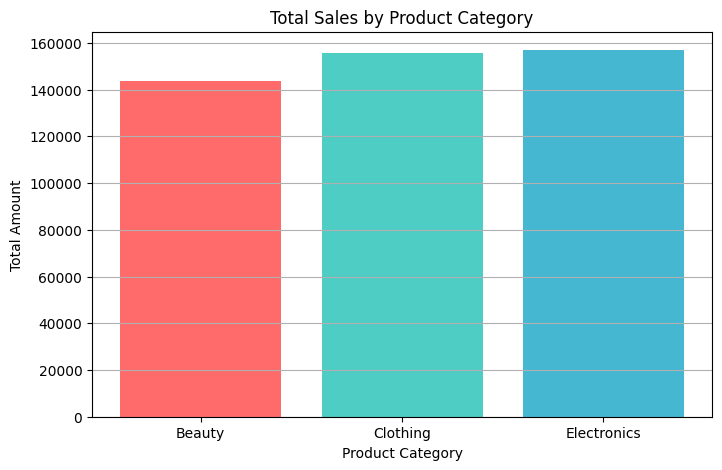

In [8]:
# Step 6 - Bar Chart: Sales by Category
plt.figure(figsize=(8,5))
category_sales = df.groupby('Product Category')['Total Amount'].sum()
plt.bar(category_sales.index, category_sales.values, 
        color=['#FF6B6B','#4ECDC4','#45B7D1'])
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y')
plt.show()

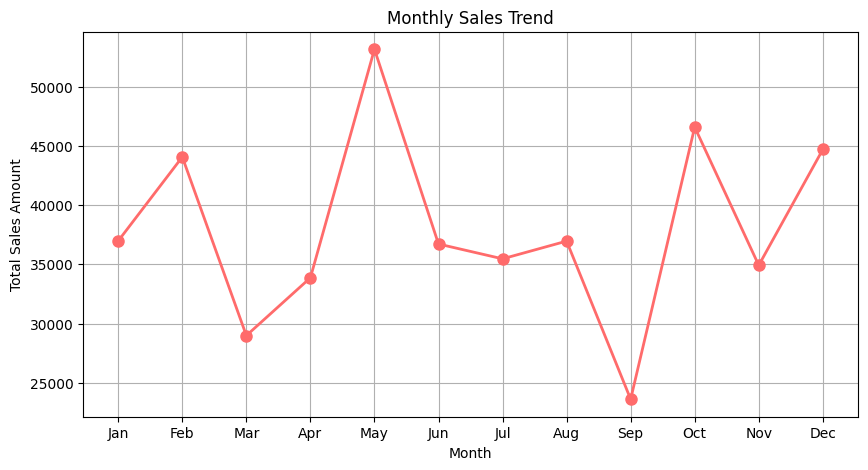

In [9]:
# Step 7 - Line Chart: Monthly Sales Trend
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, 
         marker='o', color='#FF6B6B', linewidth=2, markersize=8)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May',
           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.show()

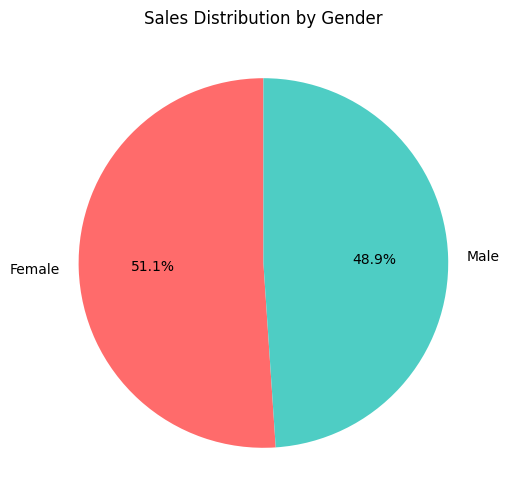

In [10]:
# Step 8 - Pie Chart: Sales by Gender
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6,6))
plt.pie(gender_sales.values, labels=gender_sales.index,
        autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4'],
        startangle=90)
plt.title('Sales Distribution by Gender')
plt.show()

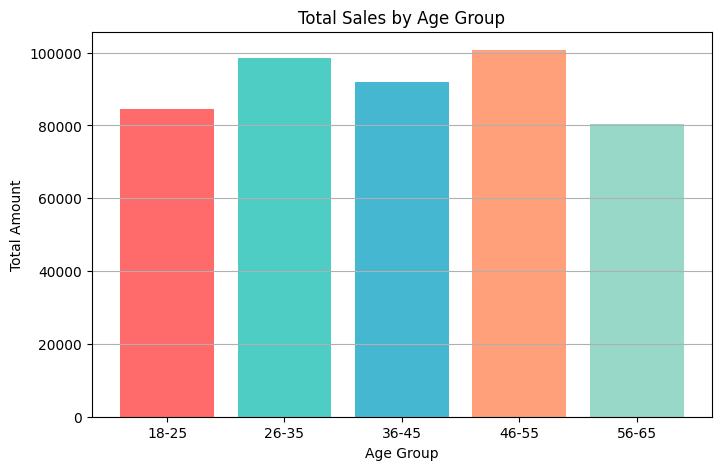

In [11]:
# Step 9 - Bar Chart: Sales by Age Group
age_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

plt.figure(figsize=(8,5))
plt.bar(age_sales.index, age_sales.values,
        color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A','#98D8C8'])
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.grid(axis='y')
plt.show()

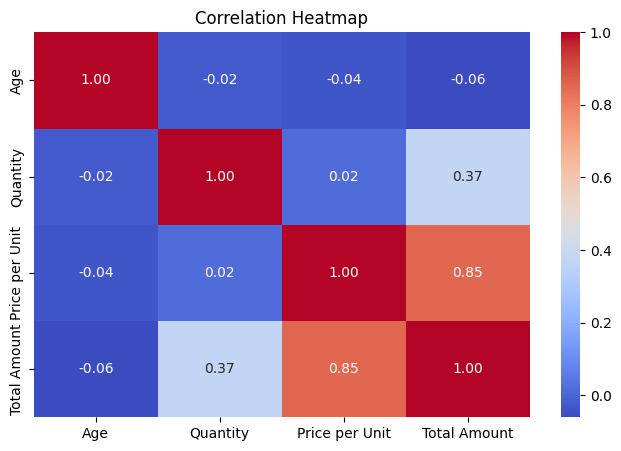

In [12]:
# Step 10 - Heatmap: Correlation
plt.figure(figsize=(8,5))
correlation = df[['Age','Quantity','Price per Unit','Total Amount']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

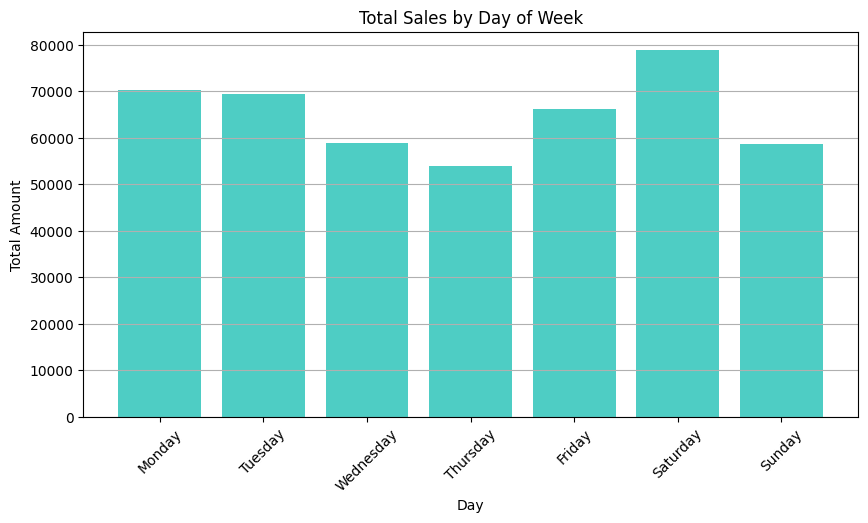

In [13]:
# Step 11 - Sales by Day of Week
df['Day'] = df['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('Day')['Total Amount'].sum().reindex(day_order)

plt.figure(figsize=(10,5))
plt.bar(day_sales.index, day_sales.values, color='#4ECDC4')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

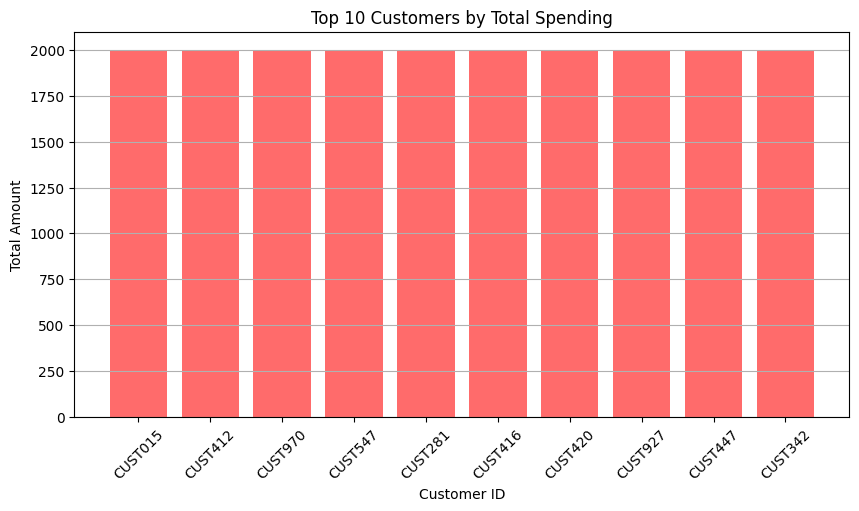

In [14]:
# Step 12 - Top 10 Customers by Spending
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_customers.index, top_customers.values, color='#FF6B6B')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [15]:
# Step 13 - Final Summary
print("=" * 50)
print("       EDA ON RETAIL SALES DATA - SUMMARY")
print("=" * 50)

print(f"\n Total Transactions: {len(df)}")
print(f" Total Revenue: {df['Total Amount'].sum()}")
print(f" Average Purchase Value: {df['Total Amount'].mean():.2f}")

print("\n=== TOP FINDINGS ===")
print(f" Best Category: {df.groupby('Product Category')['Total Amount'].sum().idxmax()}")
print(f" Best Month: {df.groupby('Month_Name')['Total Amount'].sum().idxmax()}")
print(f" Top Gender: {df.groupby('Gender')['Total Amount'].sum().idxmax()}")
print(f" Most Active Age Group: {df.groupby('Age Group', observed=True)['Total Amount'].sum().idxmax()}")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Focus marketing on Electronics category")
print(" 2. Target Female customers with special offers")
print(" 3. Run promotions during low sales months")
print(" 4. Focus on age group that spends the most")
print("=" * 50)
print(" EDA Completed Successfully!")
print("=" * 50)

       EDA ON RETAIL SALES DATA - SUMMARY

 Total Transactions: 1000
 Total Revenue: 456000
 Average Purchase Value: 456.00

=== TOP FINDINGS ===
 Best Category: Electronics
 Best Month: May
 Top Gender: Female
 Most Active Age Group: 46-55

=== RECOMMENDATIONS ===
 1. Focus marketing on Electronics category
 2. Target Female customers with special offers
 3. Run promotions during low sales months
 4. Focus on age group that spends the most
 EDA Completed Successfully!
